<a href="https://colab.research.google.com/github/KU-BIG/KUBIG_2026_SPRING/blob/main/Basic%20Study/ML/5%EC%A3%BC%EC%B0%A8/2026_1_ML_week5_%EC%9C%A4%EC%A7%80%EC%9B%90.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 (Dimension Reduction, SVM)

## Dimension Reduction

### `make_regression`을 이용한 PCA Regression

https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html

scikit-learn에서는 `make_regression` 함수를 이용하여 회귀분석을 연습하기 위한 데이터셋을 만들 수 있다. 이를 이용해서 Principal Component Regression을 연습하는 과제를 진행해보자.

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt

### Q1 `make_regression` 함수로 데이터를 생성해보자

독립변수는 X1부터 X10까지, 종속변수는 Y를 생성하자. 표본 크기는 1000으로 설정하고, `noise`, `random_state`, `bias`등의 변수는 자유롭게 설정해보자.

In [3]:
# make_regression로 데이터 생성
X, y, coef = make_regression(
    n_samples=1000,      # 표본 크기
    n_features=10,       # X1 ~ X10
    noise=15.0,          # 노이즈
    bias=5.0,            # 절편
    coef=True,           # true coefficient 반환
    random_state=42
)

#df 로 만들기
X_columns = [f"X{i}" for i in range(1, 11)]
df = pd.DataFrame(X, columns=X_columns)
df["Y"] = y


### Q2 EDA를 해보자

각 변수별 히스토그램, scatterplot matrix, correlation matrix, 요약통계량(descriptive statistics)를 그려보자


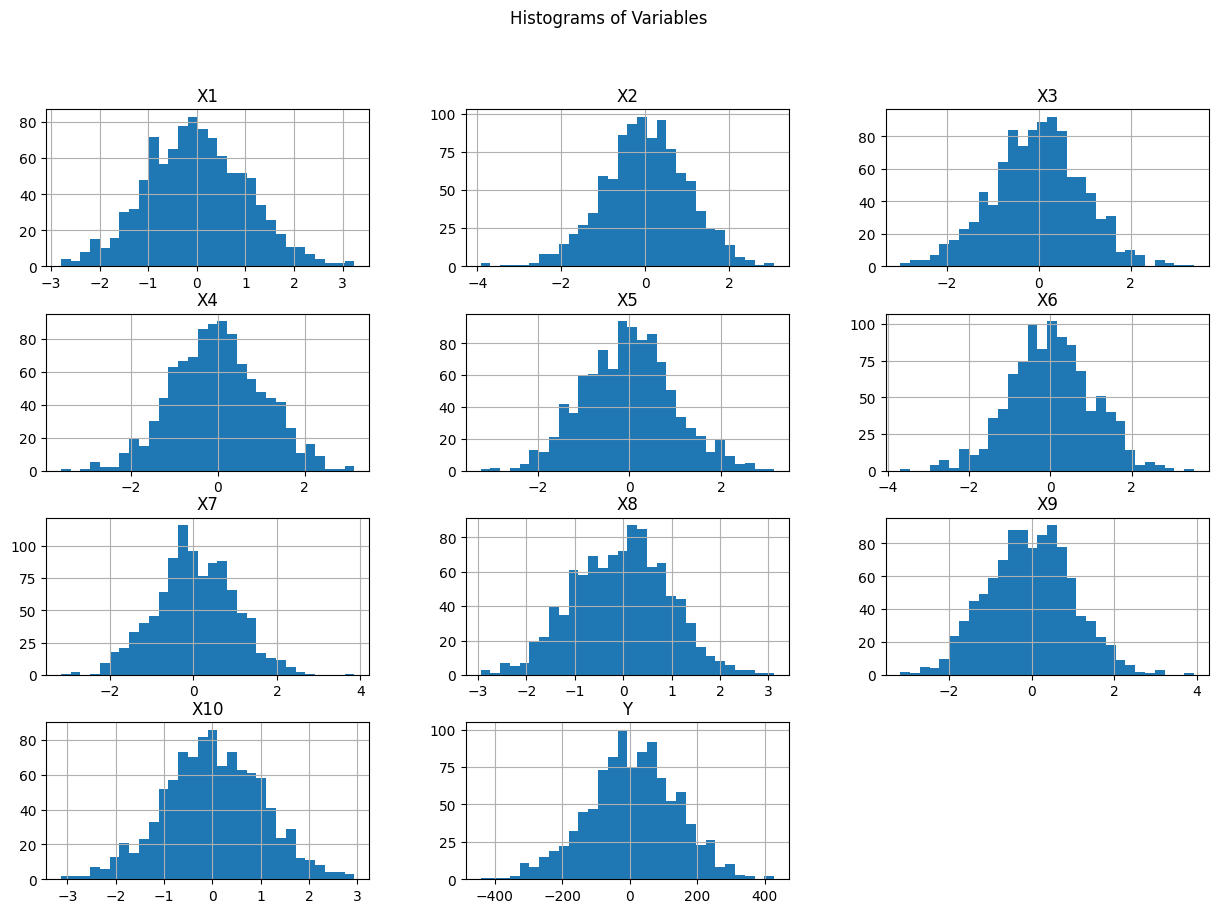

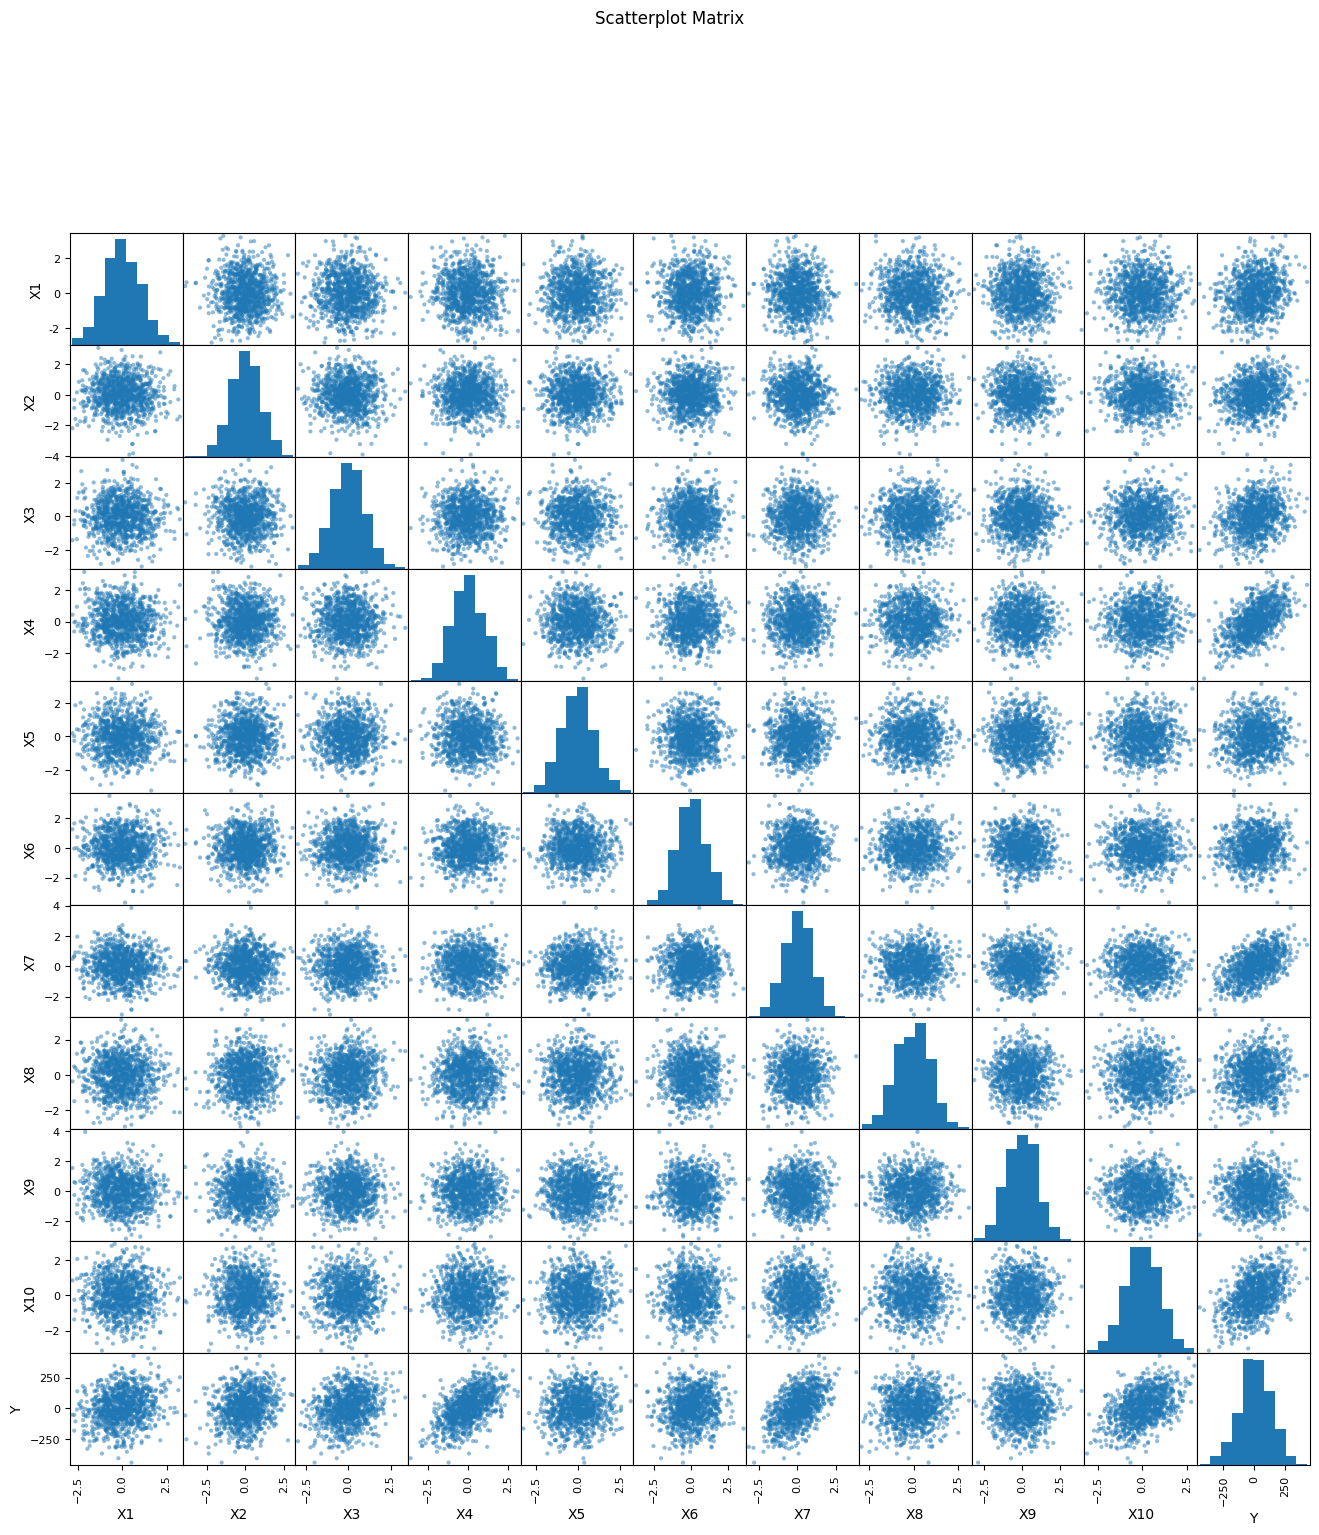

           X1        X2        X3        X4        X5        X6        X7  \
X1   1.000000 -0.014729 -0.022970 -0.047760  0.005300  0.003115 -0.040194   
X2  -0.014729  1.000000 -0.029257 -0.025767  0.029890  0.015505 -0.037738   
X3  -0.022970 -0.029257  1.000000 -0.000282 -0.012145  0.044905  0.013660   
X4  -0.047760 -0.025767 -0.000282  1.000000 -0.031427  0.034324 -0.004021   
X5   0.005300  0.029890 -0.012145 -0.031427  1.000000  0.001060  0.029390   
X6   0.003115  0.015505  0.044905  0.034324  0.001060  1.000000 -0.000379   
X7  -0.040194 -0.037738  0.013660 -0.004021  0.029390 -0.000379  1.000000   
X8  -0.027056  0.025906  0.083381  0.017622 -0.014704 -0.015515  0.025116   
X9  -0.062372 -0.027021  0.004552  0.006214  0.009023 -0.031786 -0.007680   
X10 -0.008900 -0.017387  0.028298  0.014265  0.010855  0.010398  0.003800   
Y    0.194991  0.190876  0.233126  0.565880  0.059966  0.109454  0.529420   

           X8        X9       X10         Y  
X1  -0.027056 -0.062372 -0.00

In [4]:
from sklearn.datasets import make_regression
from pandas.plotting import scatter_matrix

# 히스토그램
df.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of Variables")
plt.show()

# Scatterplot matrix
scatter_matrix(df, figsize=(16, 16))
plt.suptitle("Scatterplot Matrix", y=1.02)
plt.show()

# Correlation matrix
corr_matrix = df.corr()
print(corr_matrix)

# 요약 통계량
print(df.describe())

### Q3 `StandardScaler` 로 scaling을 해보자

X 변수들에 대해 `StandarScaler`를 이용하여 표준화를 해보자.
PCA를 하기 전에 스케일링을 한다는 점을 유의하자.

In [5]:
from sklearn.preprocessing import StandardScaler

# 스케일링하기
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Q4 `PCA`를 해보자

`PCA` 함수를 이용하여 PCA를 해보자. 또 다음을 해보자.

- PC1 부터 PC10 까지 Scree plot을 그려보자
- PC1과 PC2를 가지고 scatterplot을 그려보자.

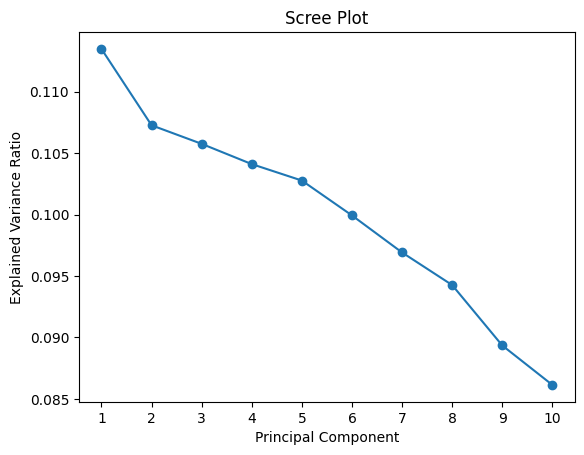

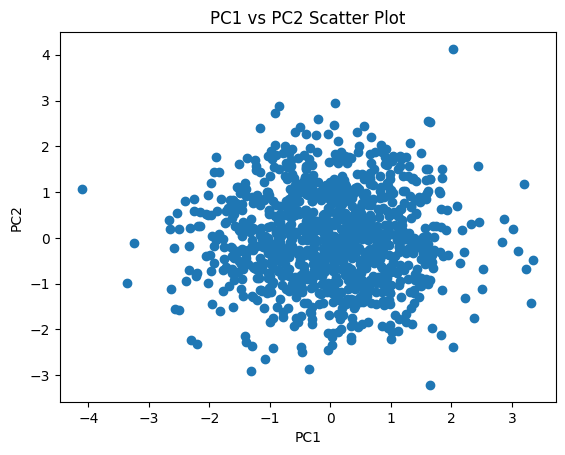

In [6]:
from sklearn.decomposition import PCA

# PCA 계산하기: 10개의 x변수들을, 분산을 가장 잘 설명하는 새로운 축들로 회전시키는 것.
# PC1=a1​X1​+a2​X2​+⋯+a10​X10​
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
X_pca

# Scree plot 그리기: PC마다 설명하는 분산의 크기를 그림으로 본 것.
# PC1-> PC2 방향이 가장 변화가 큼, 그 이후에는 크게 변화하는 elbow 없음.
import matplotlib.pyplot as plt
import numpy as np

explained_var = pca.explained_variance_ratio_

plt.figure()
plt.plot(
    range(1, 11),
    explained_var,
    marker='o'
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.xticks(range(1, 11))
plt.show()


# PC1 와 PC2 산점도 그리기: x1~x10 공간의 데이터를 pc1-pc2 공간으로 투영해서 본 산점도
# 즉, 데이터를 가장 잘 설명하는 2차원(분산이 가장 큰 두 방향)에서 본 모습.

# 아래의 데이터를 보면, pc1과 pc2의 산점도가 원형의 구름 형태로 나타남
# 즉, 변수 간 상관이 거의 없는 상황, 어느 방향으로 봐도 분산이 비슷하며, 특별히 중요한 방향이 없음.

plt.figure()
plt.scatter(
    X_pca[:, 0],  # PC1
    X_pca[:, 1]   # PC2
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 Scatter Plot")
plt.show()



### Q5 `train_test_split`을 해보자

Train set과 Test set을 6:4 비율로 나눠보자

In [7]:
#사실, test data set에는 fit이 되면 안되기 때문에, transfrom을 하기 전에 train/test을 split하는 것이 더 정확.
from sklearn.model_selection import train_test_split

# train set과 test set 나누기
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.4,
    random_state=42
)


###  Q6 Principal Component Regression을 진행해보자.

Q5에서 만든 데이터로부터 다음의 과정으로 문제를 풀어보자.
- Y를 종속변수(`y_train`), `X_train`의 PC1을 종속변수로 하여 Linear Regression을 적합한다.
- `y_pred`과 `y_train`을 비교하여 train error의 MSE를 구한다.
- Principal component을 하나 늘려 Linear regression을 적합한다. 즉 Y에 대해 PC1, PC2으로 Linear Regression을 적합한다.
- 마찬가지로 train error의 MSE를 구한다.
- PC10까지 같은 과정을 반복하고, MSE를 비교한다.



In [8]:
#PCR: PCA를 만든 주성분(PC)를 가지고 선형회귀를 하는 것.

from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#PCA를 train data set fit하는 과정(아까는 전체 data set에 대하여 pca를 적용)
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# train MSE 저장
mse_train = []


# 회귀모형 적합
for k in range(1, 11):

    # PC1 ~ PCk 사용
    X_train_k = X_train_pca[:, :k]

    # 회귀모형 적합
    model = LinearRegression()
    model.fit(X_train_k, y_train)

    # train 예측
    y_pred_train = model.predict(X_train_k)

    # train MSE 계산
    mse = mean_squared_error(y_train, y_pred_train)
    mse_train.append(mse)

# 결과 출력
for i, mse in enumerate(mse_train, start=1):
    print(f"PC 1~{i} 사용, Train MSE: {mse:.4f}")

#PC10에서 급격한 MSE의 감소(elbow rule)는 10개 변수가 모두 실제 signal을 갖고 있을 가능성이 높다는 것을 의미
#따라서 최적 pc개수 10개로 판단.
#이러한 결과는 해당 데이터가 make_regression 함수 사용하여 완전한 선형구조+적은 noise의 데이터 구조를 띄기 때문에 발생.

PC 1~1 사용, Train MSE: 16273.7466
PC 1~2 사용, Train MSE: 15902.5527
PC 1~3 사용, Train MSE: 13845.4301
PC 1~4 사용, Train MSE: 13845.3744
PC 1~5 사용, Train MSE: 11449.5305
PC 1~6 사용, Train MSE: 10796.1183
PC 1~7 사용, Train MSE: 9630.3774
PC 1~8 사용, Train MSE: 9616.3352
PC 1~9 사용, Train MSE: 3024.0421
PC 1~10 사용, Train MSE: 205.7584


### Q7 Test error을 계산해보자.

위 과정에서 적합한 모형을 바탕으로 `y_test`을 추정하고 `y_test`와의 MSE를 계산하여 test error을 구해보자.

In [10]:
# test MSE 저장
mse_test = []

for k in range(1, 11):

    # PC 1~k개 사용
    X_train_k = X_train_pca[:, :k]
    X_test_k = X_test_pca[:, :k]

    # 회귀모형 적합
    model = LinearRegression()
    model.fit(X_train_k, y_train)

    # test 예측
    y_pred_test = model.predict(X_test_k)

    # test MSE 계산
    mse = mean_squared_error(y_test, y_pred_test)
    mse_test.append(mse)

    print(f"PC 1~{k} 사용, Test MSE: {mse:.4f}")

#원래 test mse는 pc가 늘어남에도 최소가 되는 지점이 존재
#그러나 해당 데이터의 경우 make_regression 함수 사용하여 완전한 선형구조+적은 noise의 데이터 구조를 띔.
#이에 pc사용이 늘어날수록 test mse가 지속적으로 감소하며 감소율 또한 가장 큼
# 따라서 pc10개 모두 사용하는 것이 최적.

PC 1~1 사용, Test MSE: 16180.4342
PC 1~2 사용, Test MSE: 15868.7050
PC 1~3 사용, Test MSE: 13094.0923
PC 1~4 사용, Test MSE: 13092.0252
PC 1~5 사용, Test MSE: 10839.1224
PC 1~6 사용, Test MSE: 10346.1622
PC 1~7 사용, Test MSE: 9525.3101
PC 1~8 사용, Test MSE: 9533.0800
PC 1~9 사용, Test MSE: 3102.0664
PC 1~10 사용, Test MSE: 223.3059


## SVM

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.svm import SVC, SVR

- SVC (Classification)
- SVR (Regression)

### 1.1 Hard Margin Classifier

#### Q1.1 Hard Margin Classifier란? :

선형적으로 완벽하게 분리 가능한 데이터에 대해 마진을 최대화하는 선형 분류기. 즉 데이터를 100% 오류 없이 나누는 선 중에서 가장 여유 있게 나누는 선을 찾는 것.

In [12]:
# 데이터셋 생성
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8]])
y = np.array([0, 0, 0, 1, 1, 1])

#### Q1.2 위 데이터셋을 2차원의 좌표평면에 시각화해주세요.

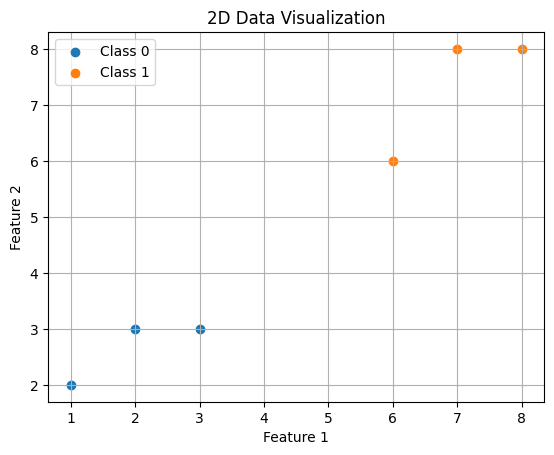

In [14]:
# 클래스별 분리
X_class0 = X[y == 0]
X_class1 = X[y == 1]

# 그래프 그리기
plt.figure()

plt.scatter(X_class0[:, 0], X_class0[:, 1], label='Class 0')
plt.scatter(X_class1[:, 0], X_class1[:, 1], label='Class 1')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('2D Data Visualization')
plt.legend()
plt.grid(True)

plt.show()

#클래스 0 중 가장 오른쪽 위 점 (3,3) 이 support vector
#클래스 1 중 가장 왼쪽 아래 점 (6,6) 이 support vector

In [15]:
# Hard Margin SVM 모델 학습
model = SVC(kernel='linear', C=1e10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

#### Q1.3 하단 w와 b는 모델 학습으로 찾아낸 Wx+b의 계수와 상수항입니다. w와 b를 정의해주세요.

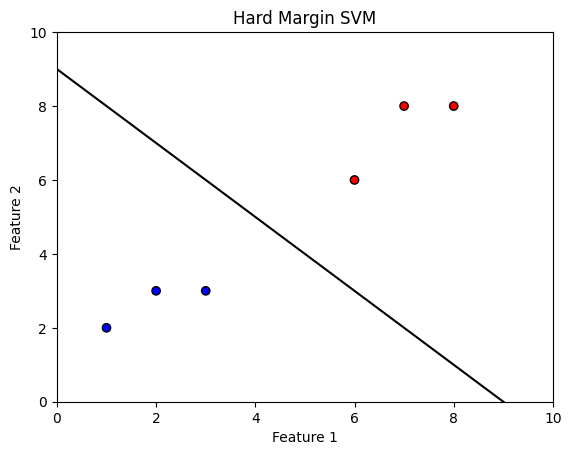

In [16]:
# 결정 경계 시각화
w = model.coef_[0]
b = model.intercept_[0]
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Hard Margin SVM')
plt.show()

### 1.2 Soft Margin Classifier

#### Q2.1 Soft Margin Classifier란?

- 현실에서는 이상치가 있고, 선형으로 완벽하게 클래스 분리를 하는 것이 어려움. (hard margin classifier의 한계)

- 이에 일부 데이터가 마진 안에 들어오거나 잘못 분류 되는 경우를 허용하되, 이에 대한 패널티를 주는 분류기가 soft margin classifier

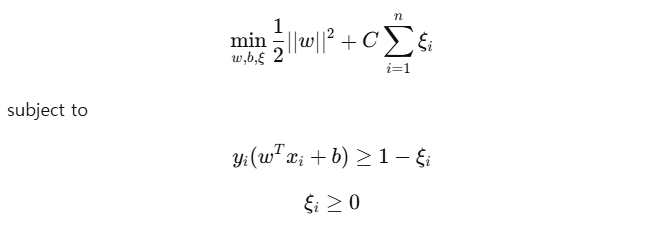

#### Q2.2 Soft Margin의 정의를 떠올리며, 노이즈가 추가된 데이터셋을 생성해주세요. (2개 이상 추가 생성 필요)

In [17]:
# 데이터셋 생성 (약간의 노이즈 추가)
X = np.array([[1, 2], [2, 3], [3, 3], [6, 6], [7, 8], [8, 8], [5,5 ], [4,4 ]])
y = np.array([0, 0, 0, 1, 1, 1, 0, 1])

In [18]:
# Soft Margin SVM 모델 학습
model = SVC(kernel='linear', C=1.0)
model.fit(X, y)

SVC(kernel='linear')

#### Q2.3 마진을 산출해 시각화하고, Support Vector을 찾아주세요.

하단 그림은 예시로, 꼭 똑같이 출력되지 않아도 됩니다.

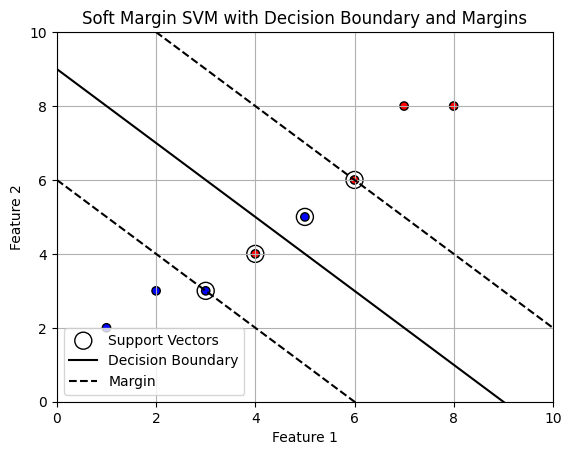

In [23]:
# 결정 경계 시각화
w = model.coef_[0]
b = model.intercept_[0]
x_plot = np.linspace(0, 10, 100)
y_plot = -(w[0] * x_plot + b) / w[1]

# 마진 경계 계산
margin = 1 / np.linalg.norm(w)  # 마진 크기 (||w||)
y_margin_positive = -(w[0] * x_plot + b - 1) / w[1]
y_margin_negative = -(w[0] * x_plot + b + 1) / w[1] #마진 경계 (w·x + b = ±1)

#support vector 표시 추가
plt.scatter(model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=150,
            facecolors='none',
            edgecolors='k',
            label='Support Vectors')

# 마진 시각화
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')
plt.plot(x_plot, y_plot, 'k-', label='Decision Boundary')
plt.plot(x_plot, y_margin_positive, 'k--', label='Margin')
plt.plot(x_plot, y_margin_negative, 'k--')

plt.xlim(0, 10)
plt.ylim(0, 10)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Soft Margin SVM with Decision Boundary and Margins')
plt.legend()
plt.grid(True)
plt.show()

#마진 위, 마진 안에 들어와 있는 4개의 점들이 support vector.

### 1.3 프로젝트 (SVC)

In [24]:
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

#### **Linear SVC**

In [25]:
iris = load_iris()

X = iris.data[:, :2]
y = iris.target

#Linear SVC
C = 1
clf = SVC(kernel = "linear", C=C)
clf.fit(X,y)

SVC(C=1, kernel='linear')

In [26]:
y_pred = clf.predict(X) # 학습 데이터의 재예측 (실습용)
confusion_matrix(y, y_pred) # 따라서, 분류 결과가 상당히 정확할 수밖에 없음을 감안해야 함

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

#### Q3.1 위 예시처럼, 옵션을 linear로 설정해도 되지만, sklearn의 LinearSVC 함수를 사용해도 구현할 수 있습니다. LinearSVC로 재구현해주세요.

In [35]:
from sklearn.datasets import load_iris
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# LinearSVC는 스케일링이 거의 필수: sklearn 이용
# 최적화 방식이 좌표 하강법. 스케일 차이가 크면 수렴이 잘 안됨. 따라서 스케일링 필요
clf_linear = make_pipeline(
    StandardScaler(),
    LinearSVC(C=C, max_iter=10000)
)

clf_linear.fit(X, y)

y_pred = clf_linear.predict(X)
confusion_matrix(y, y_pred)


array([[49,  1,  0],
       [ 1, 32, 17],
       [ 0, 11, 39]])

#### **Kernal SVC**

#### Q3.2 Kernel SCV - non-linear한 형태의 SVM을 하나 이상 구현해주세요. 동일하게, 학습데이터를 predict하여 confusion matrix를 구해주세요.

In [30]:
#rbf(가우시안) 커널
clf_rbf = SVC(kernel = "rbf", C=C, gamma='scale')
clf_rbf.fit(X,y)

SVC(C=1)

In [31]:
y_pred_rbf = clf_rbf.predict(X)
confusion_matrix(y, y_pred_rbf)

array([[50,  0,  0],
       [ 0, 38, 12],
       [ 0, 15, 35]])

In [32]:
#polynomial kernal
clf_poly = make_pipeline(
    StandardScaler(),
    SVC(kernel='poly', degree=3, C=1)
)

clf_poly.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=1, kernel='poly'))])

In [33]:
y_pred_poly = clf_poly.predict(X)
confusion_matrix(y, y_pred_poly)

array([[48,  2,  0],
       [ 0, 47,  3],
       [ 0, 33, 17]])

#### 시각화

#### Q3.3 아래 예시 plot처럼, linear model과 non-linear 모델의 시각화 결과를 출력해주세요.

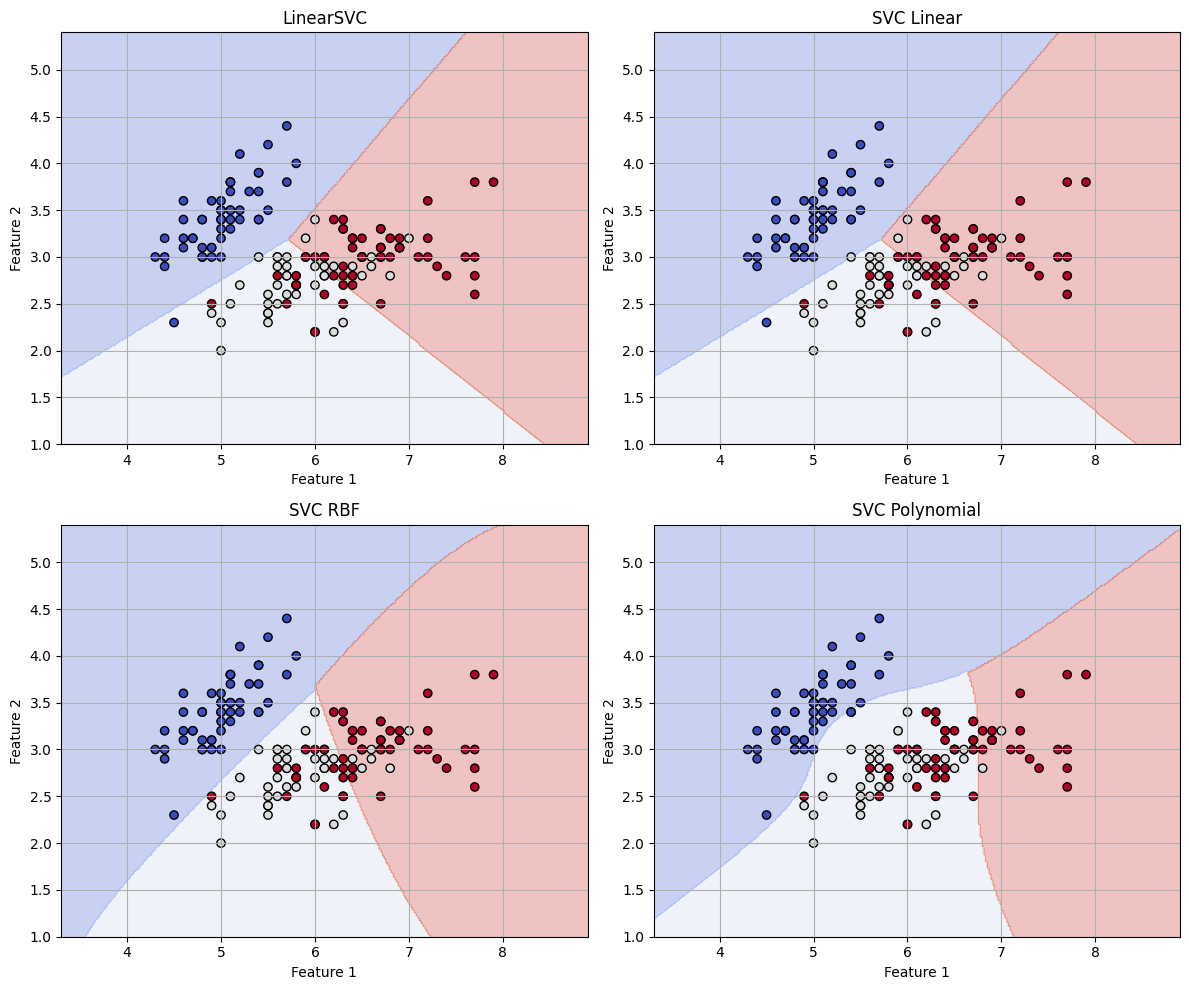

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# mesh grid 생성
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

models = [
    ("LinearSVC", clf),
    ("SVC Linear", clf_linear),
    ("SVC RBF", clf_rbf),
    ("SVC Polynomial", clf_poly)
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.ravel(), models):
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(name)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.grid(True)

plt.tight_layout()
plt.show()
